In [206]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.aln_control import Model_ALN_control
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [238]:
a = Model_ALN_control()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

[[[5.00000000e-03 2.03504329e+01 2.05955295e+01 2.09157488e+01
   2.11993731e+01 2.13902975e+01]
  [5.00000000e-03 2.03507056e+01 2.09198304e+01 2.15992279e+01
   2.21573145e+01 2.27554654e+01]]]


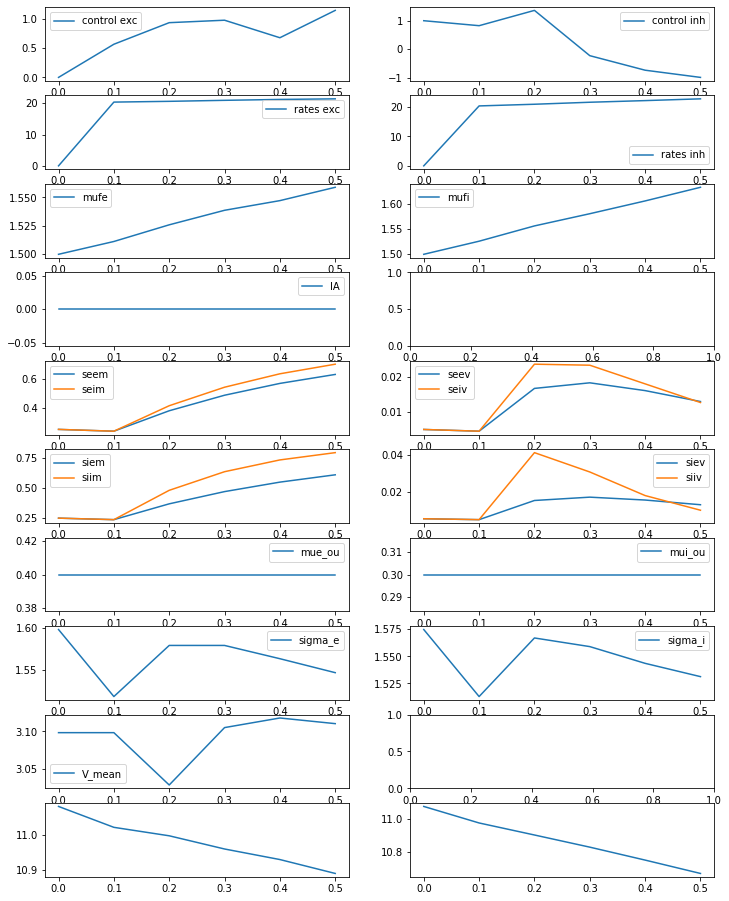

In [239]:
dur = 0.5

a.params.duration = dur
a.params.ext_exc_current = 2.
a.params.ext_inh_current = 2.

a.params.IA_init = np.array( [[0.]] )
a.params.a = 0.
a.params.b = 0.

target = a.getZeroTarget()
control1 = a.getZeroControl()

control1[0,0,5] += 1.
control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

control1[0,1,2] += 1.
control1[0,1,:] += np.cos(6.*np.arange(0,dur+a.params.dt,a.params.dt))

a.run(control=control1)

target[:,0,:] = a.state["rates_exc"][0,:]
target[:,1,:] = a.state["rates_inh"][0,:]

fig, axes = plt.subplots(10,2, figsize=(12, 16))
axes[0,0].plot(a.t, control1[0,0,:], label="control exc")
axes[0,1].plot(a.t, control1[0,1,:], label="control inh")
axes[1,0].plot(a.t, a.state["rates_exc"][0,:], label="rates exc")
axes[1,1].plot(a.t, a.state["rates_inh"][0,:], label="rates inh")
axes[2,0].plot(a.t, a.state["mufe"][0,:], label="mufe")
axes[2,1].plot(a.t, a.state["mufi"][0,:], label="mufi")
axes[3,0].plot(a.t, a.state["IA"][0,:], label="IA")

axes[4,0].plot(a.t, a.state["seem"][0,:], label="seem")
axes[4,0].plot(a.t, a.state["seim"][0,:], label="seim")
axes[5,0].plot(a.t, a.state["siem"][0,:], label="siem")
axes[5,0].plot(a.t, a.state["siim"][0,:], label="siim")

axes[4,1].plot(a.t, a.state["seev"][0,:], label="seev")
axes[4,1].plot(a.t, a.state["seiv"][0,:], label="seiv")
axes[5,1].plot(a.t, a.state["siev"][0,:], label="siev")
axes[5,1].plot(a.t, a.state["siiv"][0,:], label="siiv")

axes[6,0].plot(a.t, a.state["mue_ou"][0,:], label="mue_ou")
axes[6,1].plot(a.t, a.state["mui_ou"][0,:], label="mui_ou")

axes[7,0].plot(a.t, a.state["sigmae_f"][0,:], label="sigma_e")
axes[7,1].plot(a.t, a.state["sigmai_f"][0,:], label="sigma_i")
axes[8,0].plot(a.t, a.state["Vmean_exc"][0,:], label="V_mean")
axes[9,0].plot(a.t, a.state["tau_exc"][0,:], label="tau_exc")
axes[9,1].plot(a.t, a.state["tau_inh"][0,:], label="tau_inh")

for i in range(9):
    for j in range(2):
        if ((i,j) != (3,1) and (i,j) != (8,1)):
            axes[i,j].legend()

print(target)

In [240]:
max_cntrl = 10. * 5.
start_step = 10.
cost_params = [1.0, 2.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.rates_inh_init,
                             a.params.mufe_init, a.params.mufi_init, a.params.IA_init,
                             a.params.seem_init, a.params.seim_init, a.params.siem_init, a.params.siim_init,
                             a.params.seev_init, a.params.seiv_init, a.params.siev_init, a.params.siiv_init,
                             a.params.mue_ou, a.params.mui_ou] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()
#control2 += 1.

max_it = 40

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

err = False
for c in range(len(A1_costA)-1):
    if A1_costA[c] < A1_costA[c+1]:
        print("ERROR in index ", c)
        err = True
        break
if not err:
    print("cost decreases throughout computation")

set cost params
RUN  0 , total integrated cost =  0.05988439468018701
RUN  1 , total integrated cost =  0.0518268441877688
RUN  2 , total integrated cost =  0.05182485515345937
RUN  3 , total integrated cost =  0.05182484656653043
RUN  4 , total integrated cost =  0.05182484653014484
RUN  5 , total integrated cost =  0.051824846529982344
RUN  6 , total integrated cost =  0.05182484652998198
RUN  7 , total integrated cost =  0.051824846529981594
RUN  8 , total integrated cost =  0.051824846529980026
RUN  9 , total integrated cost =  0.05182484652997998
RUN  10 , total integrated cost =  0.0518248465299791
RUN  11 , total integrated cost =  0.051824846529978194
RUN  12 , total integrated cost =  0.05182484652997735
RUN  13 , total integrated cost =  0.051824846529977195
RUN  14 , total integrated cost =  0.05182484652997671
RUN  15 , total integrated cost =  0.05182484652997563
RUN  16 , total integrated cost =  0.0518248465299755
RUN  17 , total integrated cost =  0.0518248465299745
RUN

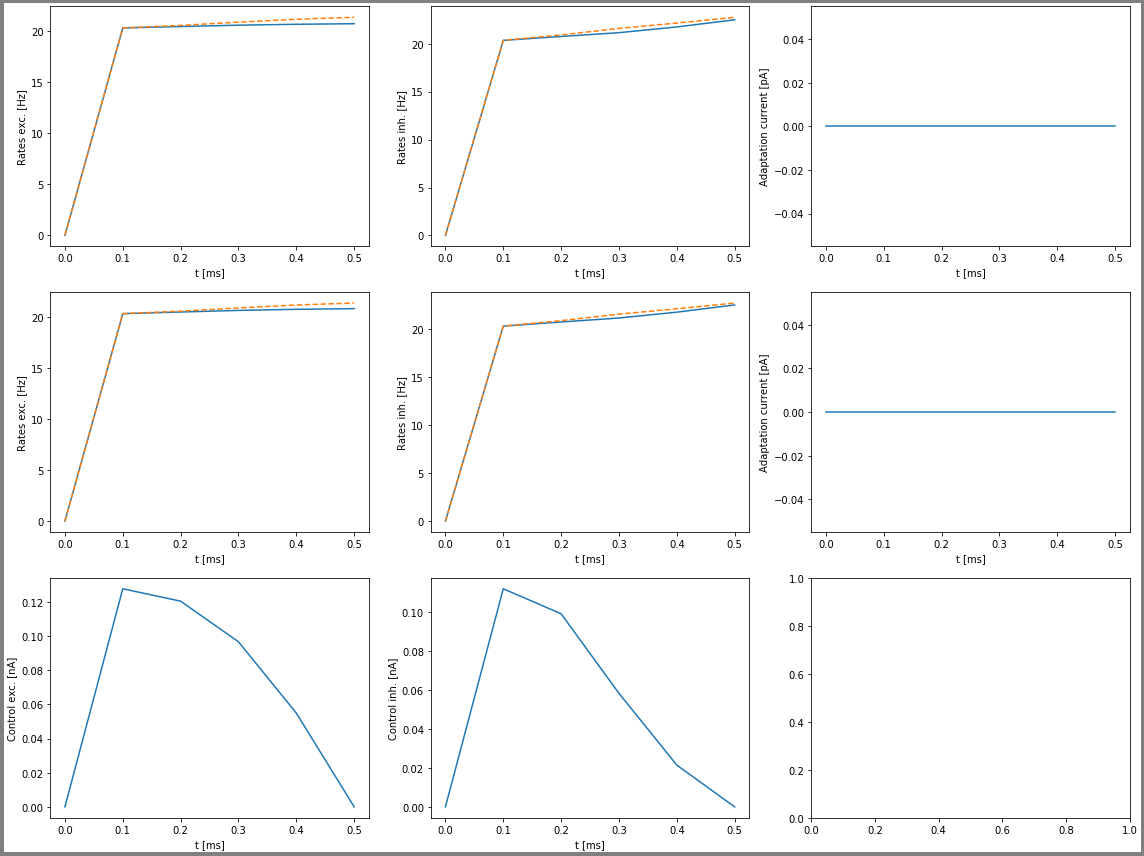

In [241]:
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [184]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 30

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  0.06328330885289699
RUN  1 , total integrated cost:  0.05440668995136252
change helped, counter =  1
change helped, counter =  1
change helped, counter =  2
RUN  2 , total integrated cost:  0.054376277084253355
change helped, counter =  1
change helped, counter =  2
RUN  3 , total integrated cost:  0.054376277045756316
change helped, counter =  3
change helped, counter =  2
change helped, counter =  3
RUN  4 , total integrated cost:  0.05437626040920765
change helped, counter =  2
RUN  5 , total integrated cost:  0.054376260409207455
change helped, counter =  4
RUN  6 , total integrated cost:  0.05437626040587057
RUN  7 , total integrated cost:  0.05437626040587053
Control only changes marginally.
RUN  8 , total integrated cost:  0.05437626040587053
Improved over  8  iterations by  15  percent.


[[[0.         0.13753422 0.13026481 0.10586687 0.0612895  0.        ]
  [0.         0.10669054 0.09359861 0.0541608  0.01949457 0.        ]]]


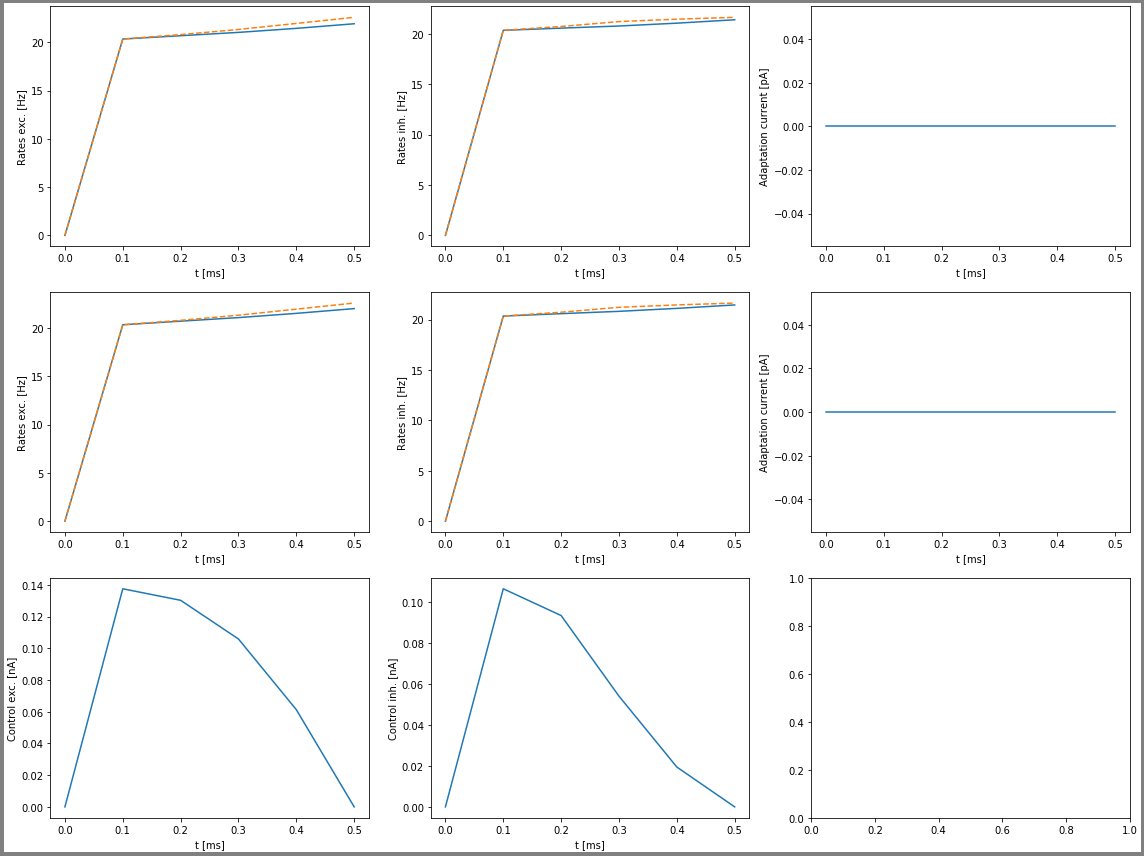

In [166]:
# 0.05372426098063908
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

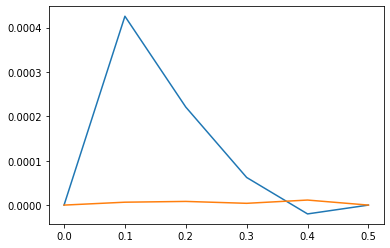

In [165]:
diff0 = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]
diff1 = A2_bestControlA[0,1,:] - A1_bestControlA[0,1,:]

plt.plot(a.t, diff0)
plt.plot(a.t, diff1)
plt.show()

(350, 64, 2)


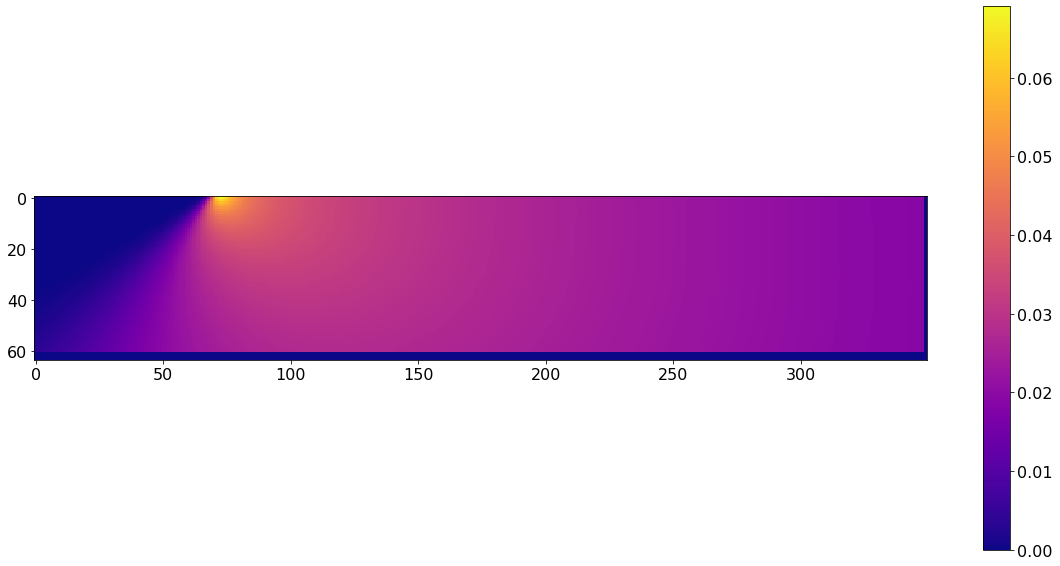

In [332]:
gradient_r = np.zeros(( len(aln.params.Irange), len(aln.params.sigmarange), 2 ))

sigma = aln.params.sigmarange[0]
mu = aln.params.Irange[0]

for sigma in range(len(aln.params.sigmarange)-3):
    for mu in range(len(aln.params.Irange)-1):
        res0 = jac_aln.der_mu(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        res1 = jac_aln.der_sigma(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        


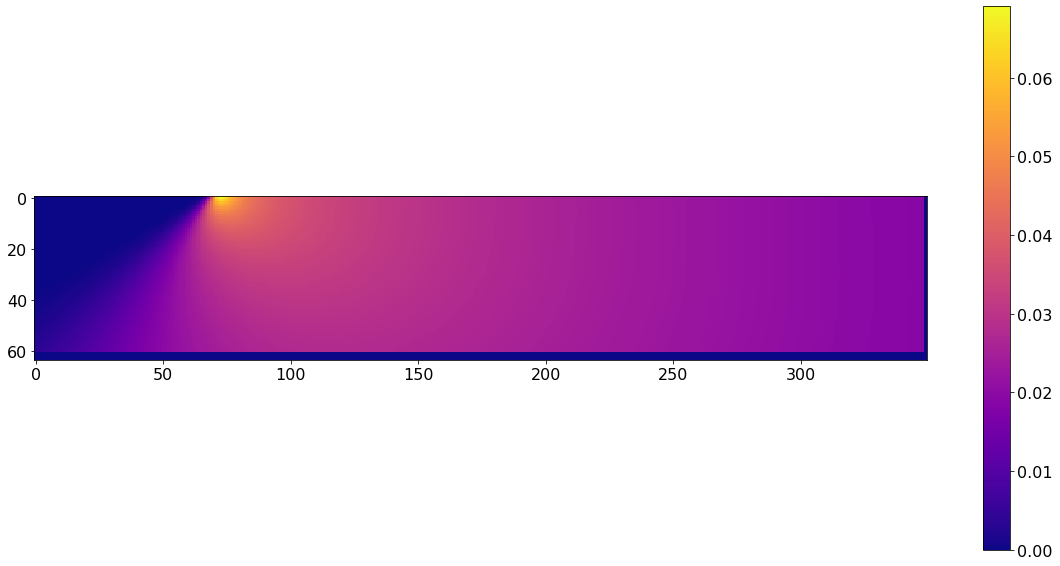

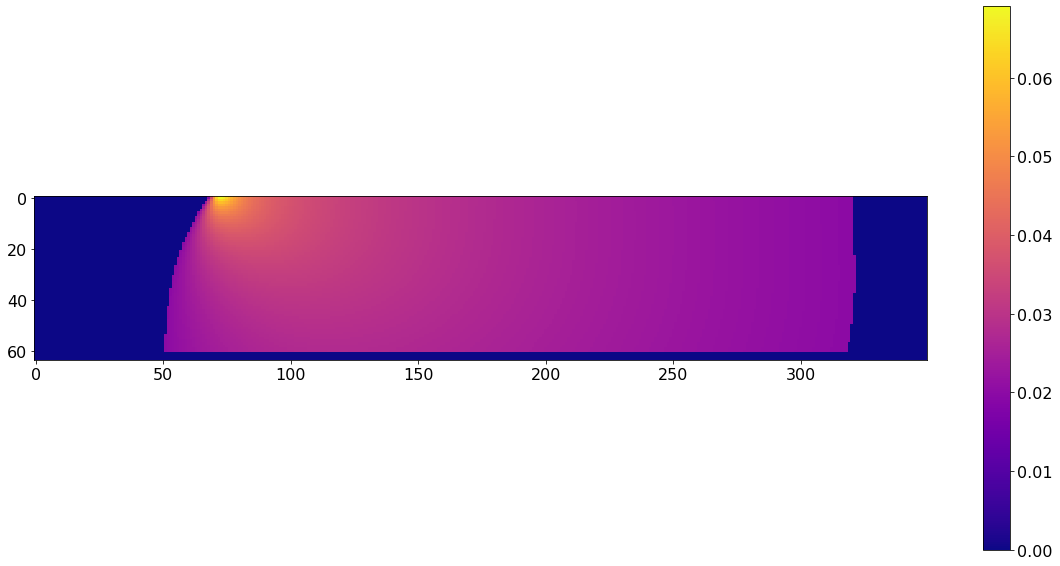

In [336]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()